## **Retail Sales & Customer Analysis**

### **Project Overview:**

This project analyzes retail transaction data to understand sales performance, customer behavior, product performance, and geographic patterns.

The dataset contains transaction-level information about invoices, products, quantities, prices, customers, dates, and countries.

---

### **Project Objectives:**

*The main objectives are to:*

- analyze overall sales performance and revenue trends;
- understand customer purchasing behavior and customer value;
- identify top-performing products and products with high sales volume;
- analyze product returns;
- compare sales performance across countries.

---

### **Tools:**

- **Python** — data cleaning, exploratory analysis, and visualization
- **PostgreSQL / SQL** — data analysis and business queries
- **Power BI** — interactive dashboard and visualization

## **1. Project Setup and Data Loading**



In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Project path
BASE_DIR = '/content/drive/MyDrive/Retail Sales & Customer Analysis'
file_path = os.path.join(BASE_DIR, 'dataset.xlsx')

# Load dataset
df = pd.read_excel(file_path)

print(f'Dataset shape: {df.shape}')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.00,United Kingdom


## **2. Data Quality Check**

A preliminary data quality check was performed to assess the dataset structure and identify potential issues before cleaning.

*The following aspects were reviewed:*

* Dataset dimensions and column structure
* Data types
* Missing values
* Duplicate records

In [2]:
# Data types
print('Data types:')
display(pd.DataFrame(df.dtypes, columns=['data_type']))

# Missing values
missing_summary = pd.DataFrame({
    'non_null_values': df.notna().sum(),
    'missing_values': df.isna().sum()
})

print('\nMissing values:')
display(missing_summary)

# Duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates:,}')

# Duplicates will be removed during the data cleaning stage

Data types:


,data_type
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object



Missing values:


,non_null_values,missing_values
InvoiceNo,541909,0
StockCode,541909,0
Description,540455,1454
Quantity,541909,0
InvoiceDate,541909,0
UnitPrice,541909,0
CustomerID,406829,135080
Country,541909,0


Duplicate rows: 5,268


### **Data Quality Check Summary:**

* Missing values are present in description and customer_id, but they do not affect the main analysis.
* 5,268 duplicate rows were found and will be removed during data cleaning.
* Some data types need to be adjusted before analysis.


## **3. Data Cleaning**

The dataset was cleaned to standardize column names and data types and prepare it for analysis.

* Standardized column names.
* Kept missing `customer_id` values and replaced missing description values with "Unknown Product".
* Converted columns to appropriate data types.
* Removed duplicate rows.

In [3]:
# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
)

# Rename columns
df = df.rename(columns={
    'invoiceno': 'invoice_no',
    'stockcode': 'stock_code',
    'invoicedate': 'invoice_date',
    'unitprice': 'unit_price',
    'customerid': 'customer_id'
})

# Handle missing descriptions
df['description'] = df['description'].fillna('Unknown Product')

# Convert data types
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['customer_id'] = df['customer_id'].astype('Int64')
df['unit_price'] = pd.to_numeric(df['unit_price'])

# Remove duplicate rows
rows_before = len(df)
df = df.drop_duplicates()
duplicates_removed = rows_before - len(df)

print(f'Duplicates removed: {duplicates_removed:,}')

Duplicates removed: 5,268


## **4. Date Range Check**

The date range was checked to understand the period covered by the dataset and identify any incomplete months.

In [4]:
# Check the date range
print(f"Start date: {df['invoice_date'].min()}")
print(f"End date: {df['invoice_date'].max()}")

print('\nDate Range:')

df['invoice_date'].dt.to_period('M').value_counts().sort_index()

Start date: 2010-01-12 08:26:00
End date: 2011-12-10 17:19:00

Date Range:


,count
invoice_date,
2010-01,3064
2010-02,2068
2010-03,2185
2010-05,2620
2010-06,3830
2010-07,2946
2010-08,2608
2010-09,2881
2010-10,2727


### **Date Range Summary:**

* The dataset covers January 2010 to December 2011.
* Some months in 2010 have no recorded transactions.
* December 2011 is incomplete and is excluded from monthly comparisons.

## **5. Post-Cleaning Data Audit**

A final check was performed to verify the dataset structure, data types, and remaining missing values.



In [5]:
# Dataset dimensions after cleaning
print(f'Rows after cleaning: {df.shape[0]:,}')
print(f'Columns after cleaning: {df.shape[1]}')


# Data types after cleaning
print('\nData types after cleaning:')
display(pd.DataFrame(df.dtypes, columns=['data_type']))


# Remaining missing values
remaining_missing = (
    df.isna()
      .sum()
      .reset_index()
)

remaining_missing.columns = ['column', 'missing_values']


remaining_missing = remaining_missing[
    remaining_missing['missing_values'] > 0
].sort_values(by='missing_values', ascending=False)


print('\nRemaining missing values:')
display(remaining_missing)


print(f'\nDuplicate rows remaining: {df.duplicated().sum()}')

Rows after cleaning: 536,641
Columns after cleaning: 8

Data types after cleaning:


,data_type
invoice_no,object
stock_code,object
description,object
quantity,int64
invoice_date,datetime64[ns]
unit_price,float64
customer_id,Int64
country,object



Remaining missing values:


,column,missing_values
6,customer_id,135037



Duplicate rows remaining: 0


### **Post-Cleaning Data Audit Summary:**

* Column names and data types are now standardized.
* Missing values remain only in `customer_id`.
* No duplicate rows remain.
* The final cleaned dataset contains **530,651** transaction rows and is ready for further analysis.

### **6. Feature Engineering**

Revenue was calculated as `quantity` × `unit_price` for each transaction.


In [6]:
# Create revenue column
df['revenue'] = df['quantity'] * df['unit_price']

df['revenue'].head()

,revenue
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34


## **7. Descriptive Statistics**

Descriptive statistics were used to review `quantity`, `unit_price`, and `revenue` before further analysis.

In [7]:
# Calculate descriptive statistics for key numeric variables
descriptive_stats = (
    df[['quantity', 'unit_price', 'revenue']]
      .describe()
      .T
      .round(2)
)

print('Descriptive Statistics:')

descriptive_stats

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
quantity,536641.00,9.62,219.13,-80995.00,1.00,3.00,10.00,80995.00
unit_price,536641.00,4.63,97.23,-11062.06,1.25,2.08,4.13,38970.00
revenue,536641.00,18.12,380.66,-168469.60,3.75,9.87,17.40,168469.60


### **Descriptive Statistics Summary:**

* `quantity`, `unit_price`, and `revenue` show substantial variation across transactions.


## **8. Investigation of Negative Transactions**

Negative values identified in the descriptive statistics were investigated to determine whether they represent data quality issues or valid business transactions, such as returns or cancellations.

In [8]:
# Check negative values
negative_quantity = (df['quantity'] < 0).sum()
negative_unit_price = (df['unit_price'] < 0).sum()
negative_revenue = (df['revenue'] < 0).sum()
negative_quantity_revenue = (
    (df['quantity'] < 0) & (df['revenue'] < 0)
).sum()

print(f'Negative `quantity` values: {negative_quantity:,}')
print(f'Negative `unit_price` values: {negative_unit_price:,}')
print(f'Negative `revenue` values: {negative_revenue:,}')
print(f'Negative `quantity` & `revenue`: {negative_quantity_revenue:,}')

Negative `quantity` values: 10,587
Negative `unit_price` values: 2
Negative `revenue` values: 9,253
Negative `quantity` & `revenue`: 9,251


### **Negative Transactions Investigation Summary:**

* Negative `quantity` and `revenue` values are treated as returns or cancellations.
* **9,251 of 9,253** negative revenue records also have negative `quantity`, showing a strong link between the two.
* Only 2 records have a negative `unit_price`.

Gross and net revenue are calculated separately in the further analysis.


## **9. Sales Transactions Dataset**

A separate sales dataset was created using transactions with positive `quantity` and `unit_price`.

This dataset is used for gross sales and customer behavior analysis, while the full dataset is retained for net revenue calculations.

In [9]:
# Create a sales-only dataset
sales_df = df[
    (df['quantity'] > 0) &
    (df['unit_price'] > 0)
].copy()


# Revenue analysis
gross_revenue = sales_df['revenue'].sum()
returns_value = abs(df[df['revenue'] < 0]['revenue'].sum())
net_revenue = df['revenue'].sum()

print(f'Sales transactions: {len(sales_df):,}')
print(f'Gross revenue: £{gross_revenue:,.2f}')
print(f'Returns value: £{returns_value:,.2f}')
print(f'Net revenue: £{net_revenue:,.2f}')
print(f'Check (gross - returns): £{gross_revenue - returns_value:,.2f}')

Sales transactions: 524,878
Gross revenue: £10,642,110.80
Returns value: £916,103.85
Net revenue: £9,726,006.95
Check (gross - returns): £9,726,006.95


### **Sales Transactions Dataset Summary:**

* Gross revenue was **£10.64M**.
* Returns reduced net revenue to **£9.73M**.
* Gross revenue minus returns matches the calculated net revenue.

## **10. KPI Analysis**

Key performance indicators were calculated using positive sales transactions to measure revenue, customer activity, and purchasing behavior.

The analysis includes revenue, transactions, customers, average order value, purchase frequency, and items per order.


In [34]:
# Calculate sales metrics (positive transactions only)
num_transactions = sales_df['invoice_no'].nunique()
total_quantity_sold = sales_df['quantity'].sum()
paying_customers = sales_df['customer_id'].nunique()


aov = gross_revenue / num_transactions
arppu = gross_revenue / paying_customers
purchase_frequency = num_transactions / paying_customers
items_per_order = total_quantity_sold / num_transactions


# KPI summary table
kpi_summary = pd.DataFrame({
    'metric': [
        'Gross Revenue',
        'Returns Value',
        'Net Revenue',
        'Number of Transactions',
        'Total Quantity Sold',
        'Paying Customers',
        'Average Order Value (AOV)',
        'ARPPU',
        'Purchase Frequency (PF)',
        'Items per Order (IPO)'
    ],
    'value': [
        round(gross_revenue, 2),
        round(returns_value, 2),
        round(net_revenue, 2),
        num_transactions,
        total_quantity_sold,
        paying_customers,
        round(aov, 2),
        round(arppu, 2),
        round(purchase_frequency, 2),
        round(items_per_order, 2)
    ]
})

print('KPI Summary:')

kpi_summary

KPI Summary:


,metric,value
0,Gross Revenue,10642110.80
1,Returns Value,916103.85
2,Net Revenue,9726006.95
3,Number of Transactions,19960.00
4,Total Quantity Sold,5572420.00
5,Paying Customers,4338.00
6,Average Order Value (AOV),533.17
7,ARPPU,2453.23
8,Purchase Frequency (PF),4.60
9,Items per Order (IPO),279.18


### **KPI Analysis Summary:**

* The analysis includes **19,960** sales transactions from **4,338** paying customers.
* The average order value was **£533.17**, and each paying customer made an average of **4.6** purchases.
* The average of **279.18** items per order is strongly influenced by extreme quantity values in the dataset.

## **11. Monthly Sales Analysis**

Monthly sales were analyzed to track changes in revenue, transactions, customers, and purchasing behavior over time.

### **11.1  Monthly Sales Metrics**

Monthly sales and customer metrics were aggregated to create a unified dataset for subsequent monthly performance and trend analysis.

In [11]:
# Create monthly period columns
df['invoice_month'] = df['invoice_date'].dt.to_period('M')
sales_df['invoice_month'] = sales_df['invoice_date'].dt.to_period('M')


# Use comparable full months only
start_month = pd.Period('2010-12', freq='M')
end_month = pd.Period('2011-11', freq='M')


# Calculate monthly sales metrics
monthly_sales_metrics = (
    sales_df[
        (sales_df['invoice_month'] >= start_month) &
        (sales_df['invoice_month'] <= end_month)
    ]
    .groupby('invoice_month')
    .agg(
        gross_revenue=('revenue', 'sum'),
        transactions=('invoice_no', 'nunique'),
        customers=('customer_id', 'nunique'),
        quantity_sold=('quantity', 'sum')
    )
    .reset_index()
)


# Calculate monthly net revenue
monthly_net_revenue = (
    df[
        (df['invoice_month'] >= start_month) &
        (df['invoice_month'] <= end_month)
    ]
    .groupby('invoice_month')['revenue']
    .sum()
    .reset_index(name='net_revenue')
)


# Add net revenue table
monthly_sales_metrics = monthly_sales_metrics.merge(
    monthly_net_revenue,
    on='invoice_month'
)


# Calculate additional metrics
monthly_sales_metrics['aov'] = (
    monthly_sales_metrics['gross_revenue'] /
    monthly_sales_metrics['transactions']
)

monthly_sales_metrics['arppu'] = (
    monthly_sales_metrics['gross_revenue'] /
    monthly_sales_metrics['customers']
)

monthly_sales_metrics['pf'] = (
    monthly_sales_metrics['transactions'] /
    monthly_sales_metrics['customers']
)

monthly_sales_metrics['ipo'] = (
    monthly_sales_metrics['quantity_sold'] /
    monthly_sales_metrics['transactions']
)

monthly_sales_metrics = monthly_sales_metrics.round(2)

print('Monthly Sales Metrics:')

monthly_sales_metrics

Monthly Sales Metrics:


,invoice_month,gross_revenue,transactions,customers,quantity_sold,net_revenue,aov,arppu,pf,ipo
0,2010-12,324800.69,648,431,156826,313153.78,501.24,753.60,1.50,242.02
1,2011-01,700510.61,1325,875,410286,606057.45,528.69,800.58,1.51,309.65
2,2011-02,575211.67,1179,806,310748,541021.26,487.88,713.66,1.46,263.57
3,2011-03,756961.46,1430,943,392104,710536.41,529.34,802.72,1.52,274.20
4,2011-04,706669.41,1393,890,393816,658854.74,507.30,794.01,1.57,282.71
5,2011-05,824906.88,1647,1008,438025,731982.66,500.85,818.36,1.63,265.95
6,2011-06,786516.59,1660,1033,435858,743826.47,473.81,761.39,1.61,262.57
7,2011-07,905018.56,1686,1077,481135,842421.87,536.78,840.31,1.57,285.37
8,2011-08,753503.84,1530,955,397178,713905.41,492.49,789.01,1.60,259.59
9,2011-09,1203625.30,1764,1189,627434,990783.57,682.33,1012.30,1.48,355.69


### **11.2 Monthly Net Revenue Trend (Chart)**

* The chart shows monthly `net_revenue` from December 2010 to November 2011.

* Net revenue includes the impact of returns and cancellation transactions, providing a view of realized revenue over time.

* **Monthly net_revenue is shown for complete calendar months from December 2010 to November 2011, including the impact of returns and cancellations.**

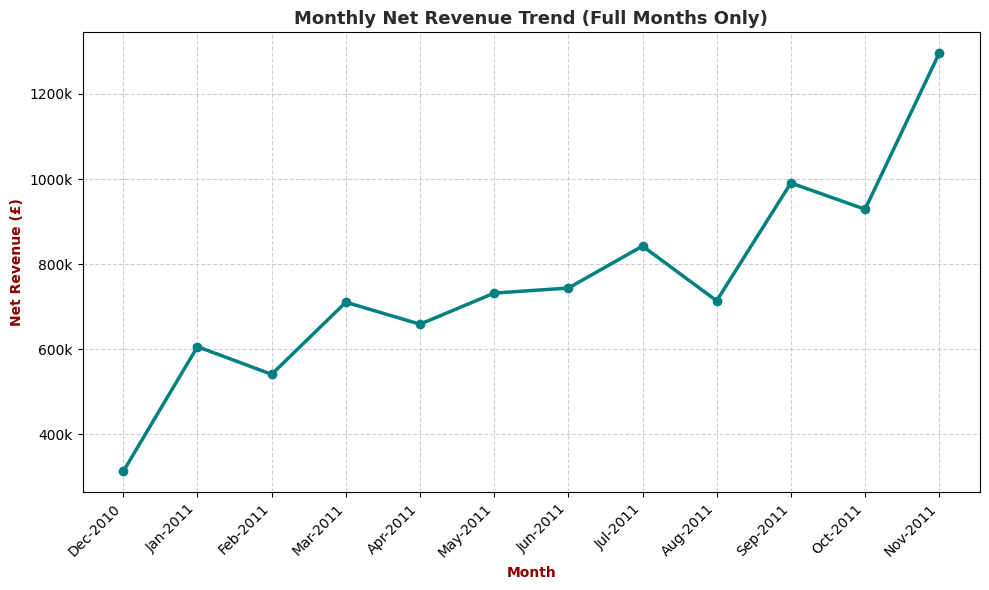

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert month labels for plotting
month_labels = monthly_sales_metrics['invoice_month'].dt.strftime('%b-%Y')


# Building chart
plt.figure(figsize=(10, 6))

plt.plot(
    month_labels,
    monthly_sales_metrics['net_revenue'],
    marker='o',
    linewidth=2.5,
    color='teal'
)

plt.title(
    'Monthly Net Revenue Trend (Full Months Only)',
    fontsize=13,
    fontweight='bold',
    color='#2B2B2B'
)

plt.xlabel(
    'Month',
    fontweight='bold',
    color='darkred'
)

plt.ylabel(
    'Net Revenue (£)',
    fontweight='bold',
    color='darkred'
)

plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.6)

# Format y-axis in thousands
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
)

plt.tight_layout()

plt.savefig(
    'monthly_net_revenue_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Monthly Net Revenue Trend Summary:**

* Net revenue shows an overall upward trend from December 2010 to November 2011.
* Growth becomes more pronounced in the second half of 2011, with September marking a turning point.
* November 2011 recorded the highest monthly net revenue at **£1.46M**.

### **11.3. Month-over-Month Change Analysis (Full Months Only)**

Month-over-month analysis was used to measure changes in `net_revenue` between consecutive full months.

Month-over-month changes were calculated for `net_revenue` using both absolute and percentage changes.

In [13]:
# MoM net revenue change analysis (full months only)

mom_net_revenue_change = pd.DataFrame({
    'nr_absolute_change': monthly_sales_metrics['net_revenue'].diff(),
    'nr_pct_change': monthly_sales_metrics['net_revenue'].pct_change() * 100
}).round(2)

print('MoM Net Revenue Change:')

mom_net_revenue_change

MoM Net Revenue Change:


,nr_absolute_change,nr_pct_change
0,NaN,NaN
1,292903.67,93.53
2,-65036.19,-10.73
3,169515.15,31.33
4,-51681.67,-7.27
5,73127.92,11.10
6,11843.81,1.62
7,98595.40,13.26
8,-128516.46,-15.26
9,276878.16,38.78


### **Month-over-Month Revenue Summary:**

* The largest month-over-month increase occurred in January 2011 **(+93.53%)**, followed by November 2011 **(+39.48%)** and October 2011 **(+38.78%)**.
* The largest decline occurred in August 2011 **(-15.26%)**, followed by February 2011 **(-10.73%)**.
* Despite month-to-month fluctuations, `net_revenue` shows an overall upward trend across the analyzed period.

### **11.4 Drivers of April Decline and September Growth**

April and September 2011 were compared across `revenue`, `transactions`, `customers`, and customer purchasing metrics to identify the main drivers of performance change.

In [14]:
# Compare April and September 2011
april_september = monthly_sales_metrics[
    monthly_sales_metrics['invoice_month'].isin([
        pd.Period('2011-04', freq='M'),
        pd.Period('2011-09', freq='M')
    ])
][[
    'invoice_month',
    'net_revenue',
    'gross_revenue',
    'transactions',
    'customers',
    'aov',
    'arppu',
    'pf'
]].copy()

print('April vs September 2011 Sales Metrics:')

april_september

April vs September 2011 Sales Metrics:


,invoice_month,net_revenue,gross_revenue,transactions,customers,aov,arppu,pf
4,2011-04,658854.74,706669.41,1393,890,507.30,794.01,1.57
9,2011-09,990783.57,1203625.30,1764,1189,682.33,1012.30,1.48


### **11.5 Drivers of April Decline and September Growth Summary:**

* Net revenue increased by **£331.93K (+50.38%)**, from **£658.85K** in April to **£990.78K** in September.
* Gross revenue increased by **70.32%**, while the number of transactions increased by **26.63%**.
* The number of paying customers increased by **33.60%**, from **890** to **1,189**.
* AOV increased by **34.51%**, from **£507.30** to **£682.33**, showing that revenue growth came from both more transactions and higher value per order.
* Purchase frequency remained relatively stable, decreasing from **1.57** to **1.48**.

## **12. Customer Analysis**

Customer analysis focuses on customer activity, purchasing frequency, and revenue contribution over the analysis period.

### **12.1. Customer Overview**

Key customer metrics were summarized to provide an overview of customer activity and revenue contribution.


In [15]:
# Customer overview
customer_overview = pd.DataFrame({
    'metric': [
        'Paying Customers',
        'Transactions',
        'ARPPU',
        'Purchase Frequency'
    ],
    'value': [
        paying_customers,
        num_transactions,
        arppu,
        purchase_frequency
    ]
}).round(2)

print('Customer Overview:')

customer_overview

Customer Overview:


,metric,value
0,Paying Customers,4338.00
1,Transactions,19960.00
2,ARPPU,2453.23
3,Purchase Frequency,4.60


### **Customer Overview Summary:**

* The analysis includes **4,338** paying customers and **19,960** sales transactions.
* Each paying customer made an average of **4.60** purchases during the analyzed period.

### **12.2. Monthly Customer Revenue Trend**

Monthly ARPPU was analyzed to track changes in average gross revenue per paying customer.

In [16]:
# Monthly ARPPU
monthly_arppu = monthly_sales_metrics[
    ['invoice_month', 'arppu']
].copy()

print('Monthly ARPPU:')

monthly_arppu

Monthly ARPPU:


,invoice_month,arppu
0,2010-12,753.60
1,2011-01,800.58
2,2011-02,713.66
3,2011-03,802.72
4,2011-04,794.01
5,2011-05,818.36
6,2011-06,761.39
7,2011-07,840.31
8,2011-08,789.01
9,2011-09,1012.30


### **Monthly Customer Revenue Trend (Chart)**

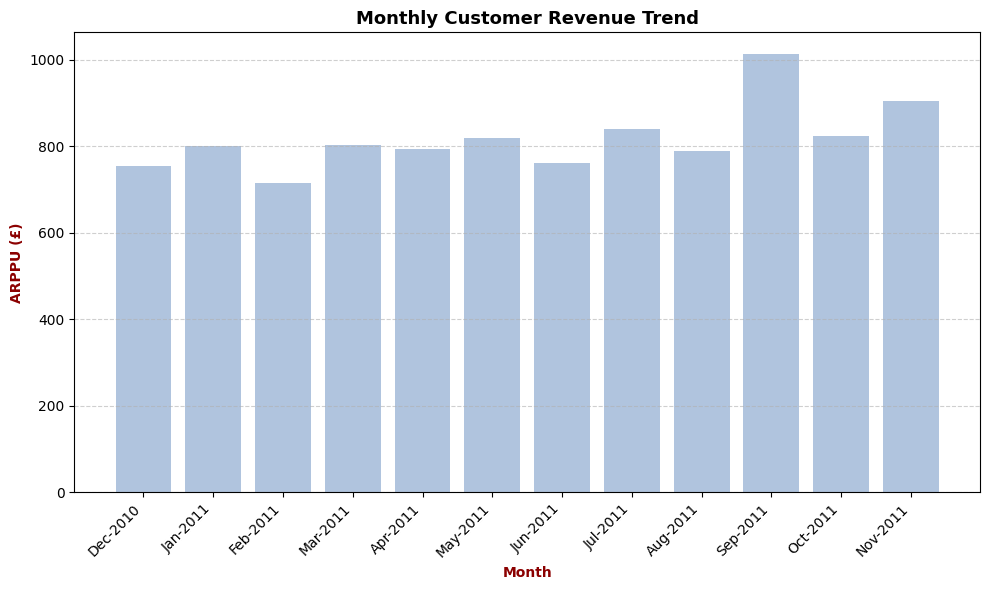

In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    month_labels,
    monthly_sales_metrics['arppu'],
    color='lightsteelblue'
)

plt.title(
    'Monthly Customer Revenue Trend',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Month',
    fontweight='bold',
    color='darkred'
)

plt.ylabel(
    'ARPPU (£)',
    fontweight='bold',
    color='darkred'
)

plt.xticks(rotation=45, ha='right')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    'monthly_arppu.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Monthly Customer Revenue Trend Summary:**

* ARPPU ranged from **£713.66** to **£1,012.30** per paying customer during the analyzed period.
* September 2011 recorded the highest ARPPU at **£1,012.30**, followed by November at **£904.02**, indicating particularly high customer value in these months.

### **12.3 Orders per Customer**

Orders per customer were analyzed to understand purchasing frequency during the analysis period.

In [18]:
# Calculate number of orders per customer
orders_per_customer = (
    sales_df.groupby('customer_id')['invoice_no']
            .nunique()
            .reset_index(name='orders')
)


# Group customers by number of orders
orders_per_customer['order_group'] = pd.cut(
    orders_per_customer['orders'],
    bins=[0, 1, 3, 5, 10, float('inf')],
    labels=[
        '1 order',
        '2–3 orders',
        '4–5 orders',
        '6–10 orders',
        '11+ orders'
    ]
)

# Summarize customer distribution
orders_distribution = (
    orders_per_customer['order_group']
    .value_counts()
    .sort_index()
    .reset_index()
)

orders_distribution.columns = ['order_group', 'customers']

# Calculate customer share
orders_distribution['share'] = (
    orders_distribution['customers']
    / orders_distribution['customers'].sum() * 100
).round(2)

print('Orders by Customer Groups')
orders_distribution

,order_group,customers,share
0,1 order,1493,34.42
1,2–3 orders,1343,30.96
2,4–5 orders,630,14.52
3,6–10 orders,535,12.33
4,11+ orders,337,7.77


### **Orders Per Customer Summary:**

* **34.42%** of paying customers made only one purchase during the analysis period.
* **30.96%** made **2–3** purchases, making it the largest repeat-purchase group.
* Customers with **4 or more purchases** accounted for **34.62%** of the customer base.

Overall, **65.58%** of paying customers made more than one purchase, so repeat customers represented the majority of the customer base.

### **12.4 Customer Concentration**

Customer concentration was analyzed to assess how much of total gross revenue was generated by the highest-value customers.

In [50]:
# Calculate revenue per customer
customer_revenue = (
    sales_df.groupby('customer_id')['revenue']
            .sum()
            .sort_values(ascending=False)
)

# Calculate the number of top customers representing 10% of the customer base
top_10_pct_count = int(len(customer_revenue) * 0.10)

# Calculate revenue generated by the top 10% of customers
top_10_pct_revenue = customer_revenue.head(top_10_pct_count).sum()

# Calculate total gross revenue
total_customer_revenue = customer_revenue.sum()

# Calculate revenue concentration
top_10_pct_share = (
    top_10_pct_revenue /
    total_customer_revenue * 100
).round(2)

top_10_pct_share

np.float64(61.41)

### **Customer Concentration Summary:**

* The **top 10% of paying customers** generated **61.41%** of total gross revenue.
* This shows that gross revenue is highly concentrated among a relatively small group of customers.
* High-value customers therefore make a substantial contribution to overall revenue.

### **12.5 Top 10 Customers**

The top 10 customers were identified based on gross revenue to assess their contribution to overall sales.

In [20]:
# Calculate total gross revenue
total_gross_revenue = customer_revenue.sum()


# Select top 10 customers
top_10_customers = (
    customer_revenue
    .head(10)
    .reset_index()
)

top_10_customers.columns = ['customer_id', 'gross_revenue']

# Calculate revenue share
top_10_customers['revenue_share'] = (
    top_10_customers['gross_revenue'] /
    total_gross_revenue * 100
).round(2)

# Round revenue
top_10_customers['gross_revenue'] = (
    top_10_customers['gross_revenue']
    .round(2)
)

print('Top 10 Customers:')

top_10_customers

Top 10 Customers:


,customer_id,gross_revenue,revenue_share
0,14646,280206.02,3.15
1,18102,259657.30,2.92
2,17450,194390.79,2.19
3,16446,168472.50,1.90
4,14911,143711.17,1.62
5,12415,124914.53,1.41
6,14156,117210.08,1.32
7,17511,91062.38,1.02
8,16029,80850.84,0.91
9,12346,77183.60,0.87


### **Top 10 Customers Summary:**

* Customer **14646** generated the highest gross revenue at **£280,206**, representing **3.15%** of total gross revenue.
* The second-highest customer generated **£259,657 (2.92%)**, so the top two customers contributed over **6%** of total gross revenue.
* The top 10 customers generated **17.31%** of total gross revenue.
* No single customer accounted for more than **3.15%** of total gross revenue, indicating that revenue was not concentrated in one individual customer.

---
### **Customer Analysis Summary**

* **65.58%** of paying customers made more than one purchase, while **34.42%** were one-time buyers.
* Customer value varied over time, with monthly ARPPU ranging from **£713.66** to **£1,012.30** and reaching its highest level in September 2011.
* The top 10% of paying customers generated **61.41%** of total gross revenue, while the top 10 individual customers accounted for **17.31%**, with the largest customer contributing **3.15%**.

Overall, revenue is driven by both a substantial repeat-customer base and a smaller group of high-value customers.

---

## **13. Product Analysis**

Product analysis focuses on product sales volume and revenue contribution to identify the products that have the greatest impact on overall sales performance.

### **13.1 Product Sales Volume**

Products were ranked by gross quantity sold to identify the items with the highest sales volume during the analysis period.

Gross quantity reflects positive sales transactions before accounting for product returns.

In [21]:
# Calculate gross quantity sold by product
product_quantity = (
    sales_df.groupby(['stock_code', 'description'])['quantity']
            .sum()
            .sort_values(ascending=False)
            .reset_index(name='gross_quantity_sold')
)

# Select top 10 products by gross quantity sold
top_10_products_quantity = (
    product_quantity
    .head(10)
)

print('Top 10 Products by Gross Quantity Sold:')

top_10_products_quantity

Top 10 Products by Gross Quantity Sold:


,stock_code,description,gross_quantity_sold
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,85099B,JUMBO BAG RED RETROSPOT,48371
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580
5,22197,POPCORN HOLDER,36749
6,21212,PACK OF 72 RETROSPOT CAKE CASES,36396
7,84879,ASSORTED COLOUR BIRD ORNAMENT,36362
8,23084,RABBIT NIGHT LIGHT,30739
9,22492,MINI PAINT SET VINTAGE,26633


### **Top 10 Products by Quantity Sold (Chart)**

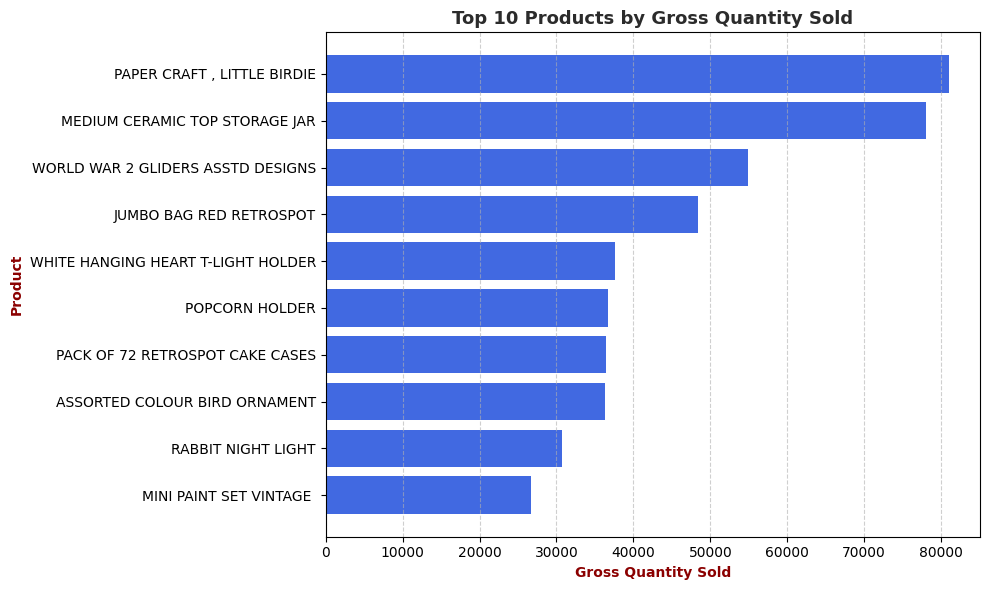

In [22]:
# Sort products for horizontal bar chart
top_10_products_quantity = (
    top_10_products_quantity
    .sort_values('gross_quantity_sold', ascending=True)
)

# Build chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_products_quantity['description'],
    top_10_products_quantity['gross_quantity_sold'],
    color='royalblue'
)

plt.title(
    'Top 10 Products by Gross Quantity Sold',
    fontsize=13,
    fontweight='bold',
    color='#2B2B2B'
)

plt.xlabel(
    'Gross Quantity Sold',
    fontweight='bold',
    color='darkred'
)

plt.ylabel(
    'Product',
    fontweight='bold',
    color='darkred'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    'top_10_products_by_gross_quantity.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Top 10 Products by Gross Quantity Sold Summary:**

* **PAPER CRAFT, LITTLE BIRDIE** recorded the highest gross quantity sold at **80,995 units**.
* **MEDIUM CERAMIC TOP STORAGE JAR** ranked second with **78,033 units**, followed by **WORLD WAR 2 GLIDERS ASSTD DESIGNS** with **54,951 units**.
* The remaining products in the Top 10 had gross sales volumes ranging from **26,633** to **48,371 units**.

Quantity sold alone does not indicate revenue contribution, so product sales value is analyzed separately.

### **13.2 Product Returns**

Product returns were analyzed to assess how returned quantities affect product sales volume.

Gross quantity sold, returned quantity, and net quantity are compared to identify products with substantial return activity.

In [31]:
# Calculate gross quantity sold by product
gross_quantity = (
    product_df[product_df['quantity'] > 0]
    .groupby(['stock_code', 'description'])['quantity']
    .sum()
    .reset_index(name='gross_quantity_sold')
)


# Calculate returned quantity by product
returned_quantity = (
    product_df[product_df['quantity'] < 0]
    .groupby(['stock_code', 'description'])['quantity']
    .sum()
    .abs()
    .reset_index(name='returned_quantity')
)


# Combine gross sales and returns
product_returns = gross_quantity.merge(
    returned_quantity,
    on=['stock_code', 'description'],
    how='left'
)


# Replace missing return quantities with 0
product_returns['returned_quantity'] = (
    product_returns['returned_quantity']
    .fillna(0)
)


# Calculate net quantity
product_returns['net_quantity'] = (
    product_returns['gross_quantity_sold']
    - product_returns['returned_quantity']
)


# Calculate return rate
product_returns['return_rate'] = (
    product_returns['returned_quantity']
    / product_returns['gross_quantity_sold']
    * 100
).round(2)


# Sort by returned quantity
product_returns = (
    product_returns
    .sort_values('returned_quantity', ascending=False)
)


print('Top 10 Products by Returned Quantity:')
display(product_returns.head(10))

Top 10 Products by Returned Quantity:


,stock_code,description,gross_quantity_sold,returned_quantity,net_quantity,return_rate
2896,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,80995.00,0.00,100.00
2326,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,74494.00,3539.00,95.46
3143,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9461,9376.00,85.00,99.10
352,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,10241,3150.00,7091.00,30.76
4328,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37584,2578.00,35006.00,6.86
406,21175,GIN + TONIC DIET METAL SIGN,11709,2030.00,9679.00,17.34
2016,22920,HERB MARKER BASIL,3423,1527.00,1896.00,44.61
1318,22273,FELTCRAFT DOLL MOLLY,4509,1447.00,3062.00,32.09
3752,47566B,TEA TIME PARTY BUNTING,2379,1424.00,955.00,59.86
12,15034,PAPER POCKET TRAVELING FAN,6591,1385.00,5206.00,21.01


### **Product Returns Summary:**

* **PAPER CRAFT, LITTLE BIRDIE** had **80,995 gross units** sold, but the same **80,995 units** were returned, resulting in **0 net units** and a **100%** return rate.
* MEDIUM CERAMIC TOP STORAGE JAR had a **95.46%** return rate, leaving only **3,539 net units** after returns.
* **ROTATING SILVER ANGELS T-LIGHT HLDR** also had an exceptionally high return rate of **99.10%**, leaving only **85 net units**.
* Other products also showed significant return activity, including **TEA TIME PARTY BUNTING (59.86%)**, **HERB MARKER BASIL (44.61%)**, and **FELTCRAFT DOLL MOLLY (32.09%)**.
* In contrast, **WHITE HANGING HEART T-LIGHT HOLDER** had a much lower return rate of **6.86%**, retaining **35,006 net units** from **37,584 gross units**.

High gross sales volume does not necessarily indicate strong net product performance.

### **13.3 Revenue by Product**

Products were ranked by net revenue to identify the products with the highest revenue contribution after accounting for returns.

In [26]:
# Calculate net revenue by product
product_revenue = (
    df.groupby(['stock_code', 'description'])['revenue']
      .sum()
      .reset_index(name='net_revenue')
)

# Sort products by net revenue
product_revenue = (
    product_revenue
    .sort_values('net_revenue', ascending=False)
)

# Select top 10 products by net revenue
top_10_products_revenue = (
    product_revenue
    .head(10)
    .copy()
)

# Round revenue
top_10_products_revenue['net_revenue'] = (
    top_10_products_revenue['net_revenue']
    .round(2)
)

top_10_products_revenue

,stock_code,description,net_revenue
5736,DOT,DOTCOM POSTAGE,206245.48
1810,22423,REGENCY CAKESTAND 3 TIER,164459.49
3544,47566,PARTY BUNTING,98243.88
5280,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97659.94
5266,85099B,JUMBO BAG RED RETROSPOT,92175.79
2690,23084,RABBIT NIGHT LIGHT,66661.63
5740,POST,POSTAGE,66230.64
1424,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
3882,84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42
3654,79321,CHILLI LIGHTS,53746.66


In [25]:
# Check non-product / service stock codes
service_records = (
    df[
        df['stock_code'].isin(['POST', 'DOT', 'M'])
    ][[
        'stock_code',
        'description'
    ]]
    .drop_duplicates()
)

print('Service Stock Codes:')

display(service_records)


# Exclude non-product records from product analysis
product_df = df[
    ~df['stock_code'].isin(['POST', 'DOT', 'M'])
].copy()


# Calculate net revenue by product
product_revenue = (
    product_df
    .groupby(['stock_code', 'description'])['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='net_revenue')
)


# Select top 10 products by net revenue
top_10_products_revenue = (
    product_revenue
    .head(10)
    .copy()
)


# Round revenue
top_10_products_revenue['net_revenue'] = (
    top_10_products_revenue['net_revenue']
    .round(2)
)


print('\nTop 10 Products by Net Revenue:')
display(top_10_products_revenue)

Service Stock Codes:


,stock_code,description
45,POST,POSTAGE
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
52262,POST,Unknown Product
136537,DOT,Unknown Product



Top 10 Products by Net Revenue:


,stock_code,description,net_revenue
0,22423,REGENCY CAKESTAND 3 TIER,164459.49
1,47566,PARTY BUNTING,98243.88
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97659.94
3,85099B,JUMBO BAG RED RETROSPOT,92175.79
4,23084,RABBIT NIGHT LIGHT,66661.63
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
6,84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42
7,79321,CHILLI LIGHTS,53746.66
8,23298,SPOTTY BUNTING,42030.67
9,22386,JUMBO BAG PINK POLKADOT,41584.43


### **Top 10 Products by Net Revenue (Chart)**

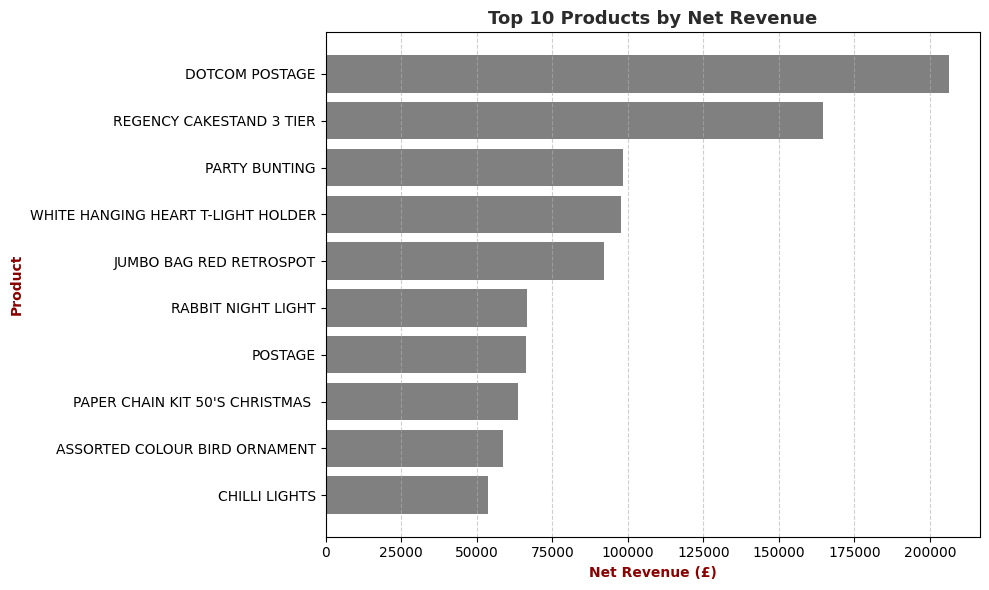

In [27]:
# Sort products for horizontal bar chart
top_10_products_revenue = (
    top_10_products_revenue
    .sort_values('net_revenue', ascending=True)
)

# Build chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_products_revenue['description'],
    top_10_products_revenue['net_revenue'],
    color='gray'
)

plt.title(
    'Top 10 Products by Net Revenue',
    fontsize=13,
    fontweight='bold',
    color='#2B2B2B'
)

plt.xlabel(
    'Net Revenue (£)',
    fontweight='bold',
    color='darkred'
)

plt.ylabel(
    'Product',
    fontweight='bold',
    color='darkred'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    'top_10_products_by_net_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Revenue by Product Summary:**

* **REGENCY CAKESTAND 3 TIER** generated the highest net revenue at **£164,459.49**, followed by **PARTY BUNTING (£98,243.88)** and **WHITE HANGING HEART T-LIGHT HOLDER (£97,659.94)**.
* The Top 10 products generated between **£41,584.43** and **£164,459.49** in net revenue.
* Several high-volume products also ranked among the Top 10 by net revenue, including **WHITE HANGING HEART T-LIGHT HOLDER**, **JUMBO BAG RED RETROSPOT**, **RABBIT NIGHT LIGHT**, and **ASSORTED COLOUR BIRD ORNAMENT**.

Sales volume and revenue contribution are not identical: high unit volume does not necessarily translate into the highest net revenue.

### **13.4 Product-level Aggregation**

A product-level summary combines key sales, return, and revenue metrics to provide a consolidated view of product performance.

In [32]:
# Combine key product-level metrics
product_summary = (
    product_returns
    .merge(
        product_revenue,
        on=['stock_code', 'description'],
        how='left'
    )
)


# Select and organize key metrics
product_summary = product_summary[[
    'stock_code',
    'description',
    'gross_quantity_sold',
    'returned_quantity',
    'net_quantity',
    'return_rate',
    'net_revenue'
]].copy()


# Round numeric metrics
product_summary['returned_quantity'] = (
    product_summary['returned_quantity'].round(0)
)

product_summary['net_quantity'] = (
    product_summary['net_quantity'].round(0)
)

product_summary['return_rate'] = (
    product_summary['return_rate'].round(2)
)

product_summary['net_revenue'] = (
    product_summary['net_revenue'].round(2)
)


# Sort by net revenue
product_summary = (
    product_summary
    .sort_values('net_revenue', ascending=False)
)


print('Product Key Metrics:')
display(product_summary.head(10))

Product Key Metrics:


,stock_code,description,gross_quantity_sold,returned_quantity,net_quantity,return_rate,net_revenue
22,22423,REGENCY CAKESTAND 3 TIER,13862,855.00,13007.00,6.17,164459.49
88,47566,PARTY BUNTING,18287,277.00,18010.00,1.51,98243.88
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37584,2578.00,35006.00,6.86,97659.94
14,85099B,JUMBO BAG RED RETROSPOT,48375,1115.00,47260.00,2.30,92175.79
249,23084,RABBIT NIGHT LIGHT,30739,108.00,30631.00,0.35,66661.63
50,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,453.00,18876.00,2.34,63715.24
314,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,80.00,36282.00,0.22,58792.42
315,79321,CHILLI LIGHTS,10305,80.00,10225.00,0.78,53746.66
244,23298,SPOTTY BUNTING,8491,110.00,8381.00,1.30,42030.67
48,22386,JUMBO BAG PINK POLKADOT,21448,456.00,20992.00,2.13,41584.43


---
### **Product Analysis Summary**

Product performance varies substantially when sales volume, returns, and net revenue are considered together.

* **PAPER CRAFT, LITTLE BIRDIE** recorded **80,995 gross units** sold, but had a **100%** return rate, resulting in zero net quantity.
* **REGENCY CAKESTAND 3 TIER** generated the highest net revenue at **£164,459.49**, despite not ranking first by gross quantity sold.
* Return rates varied considerably across products, showing that gross sales volume can overstate actual product performance.
* Several products combined high sales volume with relatively low return rates and strong net revenue.

Overall, product performance is better assessed using sales volume, returns, and net revenue together rather than gross quantity alone.

---

## **14. Geography Analysis**

This section examines the geographic distribution of sales to identify the main markets and understand where the business generates its revenue and customer activity.

### **14.1 Revenue by Country**

This analysis identifies the countries generating the highest net revenue after accounting for returns.

In [51]:
# Calculate net revenue by country
country_revenue = (
    df.groupby('country')['revenue']
      .sum()
      .reset_index(name='net_revenue')
)


# Sort countries by net revenue
top_10_countries_revenue = (
    country_revenue
    .sort_values('net_revenue', ascending=False)
    .head(10)
    .copy()
)


# Round revenue
top_10_countries_revenue['net_revenue'] = (
    top_10_countries_revenue['net_revenue']
    .round(2)
)


print('Top 10 Countries by Net Revenue:')
display(top_10_countries_revenue)

Top 10 Countries by Net Revenue:


,country,net_revenue
36,United Kingdom,8167128.18
24,Netherlands,284661.54
10,EIRE,262993.38
14,Germany,221509.47
13,France,197317.11
0,Australia,137009.77
33,Switzerland,56363.05
31,Spain,54756.03
3,Belgium,40910.96
32,Sweden,36585.41


### **Top 10 Countries by Net Revenue (Chart)**

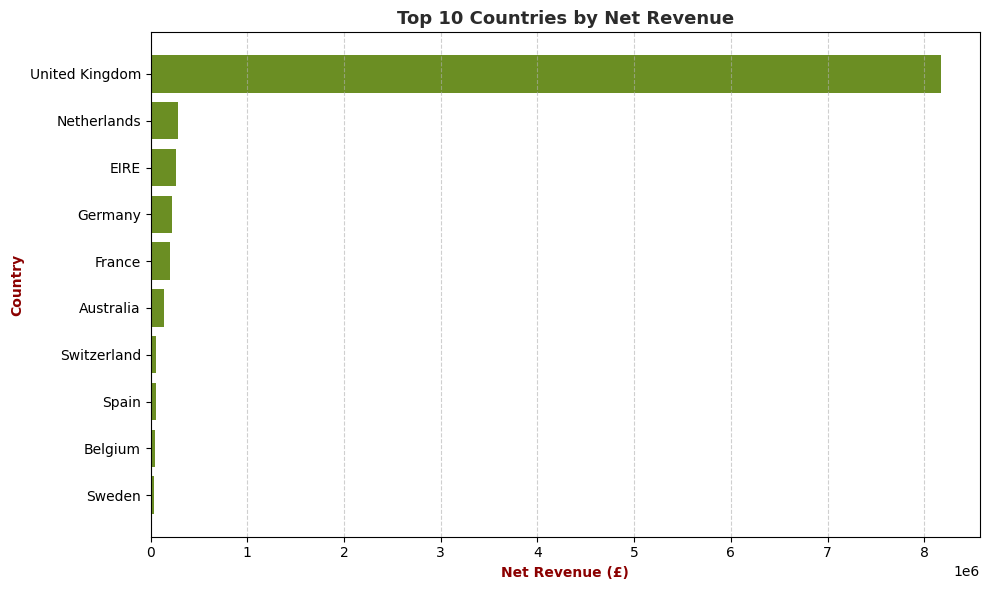

In [52]:
# Sort for horizontal bar chart
top_10_countries_revenue = (
    top_10_countries_revenue
    .sort_values('net_revenue', ascending=True)
)

# Build chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries_revenue['country'],
    top_10_countries_revenue['net_revenue'],
    color='olivedrab'
)

plt.title(
    'Top 10 Countries by Net Revenue',
    fontsize=13,
    fontweight='bold',
    color='#2B2B2B'
)

plt.xlabel(
    'Net Revenue (£)',
    fontweight='bold',
    color='darkred'
)

plt.ylabel(
    'Country',
    fontweight='bold',
    color='darkred'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    'top_10_countries_by_net_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Revenue by Country Summary:**

* **The United Kingdom** generated the highest net revenue at **£8.17M**, significantly exceeding all other markets.
* **The Netherlands (£284.66K)** ranked second, followed by **EIRE (£262.99K)** and **Germany (£221.51K)**.
* Outside the UK, the Netherlands, EIRE, Germany, and France were the strongest revenue-generating markets, although each contributed considerably less than the UK.

Overall, net revenue was highly concentrated in the UK, with international markets contributing a much smaller share.

### **14.2 Customers by Country**

This analysis shows how paying customers are distributed across countries and identifies the main customer markets.

In [53]:
# Calculate paying customers by country
country_customers = (
    sales_df
    .groupby('country')['customer_id']
    .nunique()
    .reset_index(name='customers')
)


# Sort countries by number of customers
top_10_countries_customers = (
    country_customers
    .sort_values('customers', ascending=False)
    .head(10)
    .copy()
)


print('Top 10 Countries by Paying Customers:')
display(top_10_countries_customers)

Top 10 Countries by Paying Customers:


,country,customers
36,United Kingdom,3920
14,Germany,94
13,France,87
31,Spain,30
3,Belgium,25
33,Switzerland,21
27,Portugal,19
19,Italy,14
12,Finland,12
1,Austria,11


### **Top 10 Countries by Paying Customers (Chart)**

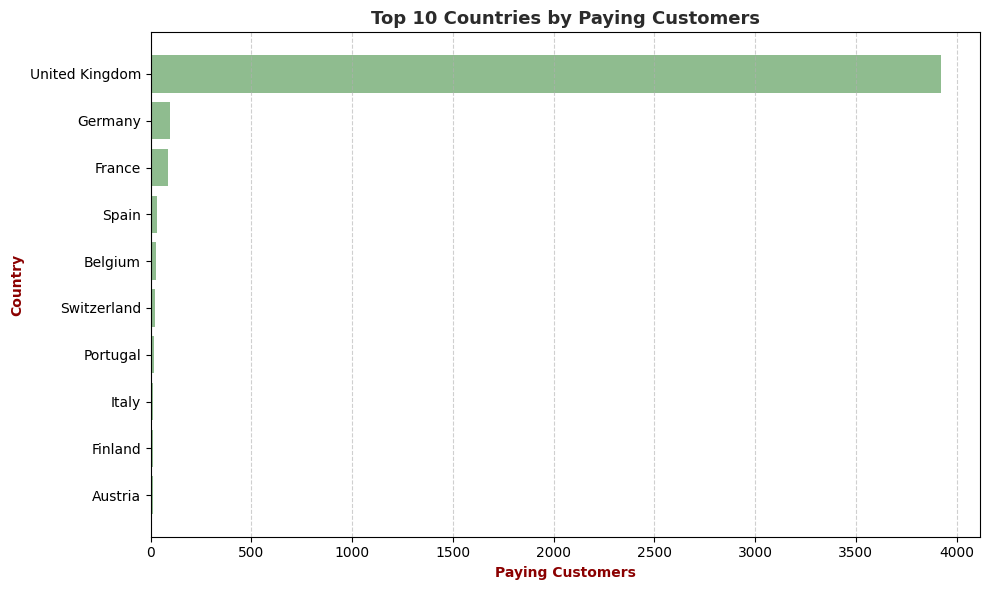

In [54]:
# Sort for horizontal bar chart
top_10_countries_customers = (
    top_10_countries_customers
    .sort_values('customers', ascending=True)
)

# Build chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries_customers['country'],
    top_10_countries_customers['customers'],
    color='darkseagreen'
)

plt.title(
    'Top 10 Countries by Paying Customers',
    fontsize=13,
    fontweight='bold',
    color='#2B2B2B'
)

plt.xlabel(
    'Paying Customers',
    fontweight='bold',
    color='darkred'
)

plt.ylabel(
    'Country',
    fontweight='bold',
    color='darkred'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    'top_10_countries_by_customers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Customers by Country Summary:**

* **The United Kingdom** had by far the largest customer base, with **3,920** paying customers.
* **Germany (94)** and **France (87)** had the largest customer bases outside the UK, although their customer counts remained substantially lower than in the UK.
* The remaining countries in the Top 10 had 30 or fewer paying customers each.

Customer distribution was therefore highly concentrated in the UK, consistent with the strong concentration of net revenue in the same market.

### **14.3 Geographic Performance**

This summary combines key customer and sales metrics by country to provide a consolidated view of geographic performance.

In [55]:
# Calculate sales metrics by country
country_sales = (
    sales_df
    .groupby('country')
    .agg(
        customers=('customer_id', 'nunique'),
        transactions=('invoice_no', 'nunique')
    )
    .reset_index()
)


# Calculate net revenue by country
country_net_revenue = (
    df
    .groupby('country')['revenue']
    .sum()
    .reset_index(name='net_revenue')
)


# Combine geographic metrics
geographic_performance = country_sales.merge(
    country_net_revenue,
    on='country',
    how='left'
)


# Sort by net revenue
geographic_performance = (
    geographic_performance
    .sort_values('net_revenue', ascending=False)
)


# Round revenue
geographic_performance['net_revenue'] = (
    geographic_performance['net_revenue']
    .round(2)
)


print('Geographic Performance:')
display(geographic_performance.head(10))

Geographic Performance:


,country,customers,transactions,net_revenue
36,United Kingdom,3920,18019,8167128.18
24,Netherlands,9,94,284661.54
10,EIRE,3,288,262993.38
14,Germany,94,457,221509.47
13,France,87,392,197317.11
0,Australia,9,57,137009.77
33,Switzerland,21,54,56363.05
31,Spain,30,90,54756.03
3,Belgium,25,98,40910.96
32,Sweden,8,36,36585.41


### **Geographic Performance Summary:**

* **The United Kingdom** was the dominant market, with **3,920** paying customers, **18,019** transactions, and **£8.17M** in net revenue.
* **The Netherlands** generated **£284.66K** in net revenue from only **9 customers** and **94** transactions, making it the second-largest market by revenue.
* **EIRE** generated **£262.99K** from just **3 customers** and **288** transactions, showing a particularly high revenue concentration among a very small customer base.
* **Germany** and **France** had much larger customer bases than most other international markets, with **94 and 87 customers** respectively, and ranked among the leading markets by net revenue.
* **Australia** generated **£137.01K** from only **9 customers**, also indicating a high revenue contribution per customer.

---
### **Geography Analysis Summary**

The geographic analysis shows a strongly UK-centered business, with a smaller group of international markets contributing additional revenue.

* **The United Kingdom** was the dominant market by both customer base and net revenue, with **3,920** paying customers and **£8.17M** in net revenue.
* International markets were much smaller in terms of customer count, but some generated substantial revenue. The Netherlands, EIRE, and Australia are notable examples.
* **Germany** and **France** had the largest customer bases outside the UK, with **94 and 87 paying customers** respectively, and were also among the leading international markets by net revenue.
* The results show that customer count does not necessarily correspond to revenue contribution across countries.

Overall, the business was highly concentrated in the UK, while a smaller number of international markets contributed additional revenue from relatively small customer bases.

---

## **15. Result Data Export**


In [60]:
# Export analysis results to Excel
output_file = 'retail_analysis_results.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:


    # Descriptive Statistics
    descriptive_stats.to_excel(
        writer,
        sheet_name='Descriptive Statistics',
        index=False
    )


    # KPI
    kpi_summary.to_excel(
        writer,
        sheet_name='KPI Summary',
        index=False
    )


     # Monthly Sales Metrics
    monthly_sales_metrics.to_excel(
        writer,
        sheet_name='Monthly Sales Metrics',
        index=False
    )


      # MoM Net Revenue Change
    mom_net_revenue_change.to_excel(
        writer,
        sheet_name='MoM Net Revenue Change',
        index=False
    )


     # Customer Overview
    customer_overview.to_excel(
        writer,
        sheet_name='Customer Overview',
        index=False
    )


     # Monthly ARPPU
    monthly_arppu.to_excel(
        writer,
        sheet_name='Monthly ARPPU',
        index=False
    )


     # Orders by Customer Groups
    orders_distribution.to_excel(
        writer,
        sheet_name='Orders_Customer Groups',
        index=False
    )


     # Top 10 Customers
    top_10_customers.to_excel(
        writer,
        sheet_name='Top 10 Customers',
        index=False
    )


     # Top 10 Products by Quantity Sold
    top_10_products_quantity.to_excel(
        writer,
        sheet_name='Top 10 Products_Quantity Sold',
        index=False
    )


     # Product Returns
    product_returns.to_excel(
        writer,
        sheet_name='Top 10 Products_Returned Quantity',
        index=False
    )


    # top 10 Products by Net Revenue
    top_10_products_revenue.to_excel(
        writer,
        sheet_name='Top 10 Products_Net Revenue',
        index=False
    )


    # Product Key Metrics
    product_summary.to_excel(
        writer,
        sheet_name='Product Key Metrics',
        index=False
    )


     # Top 10 Countries by Net Revenue
    top_10_countries_revenue.to_excel(
        writer,
        sheet_name='Top 10 Countries_Net Revenue',
        index=False
    )


     # Top 10 Countries by Customers
    top_10_countries_customers.to_excel(
        writer,
        sheet_name='Top 10 Countries_Customers',
        index=False
    )


     # Geographic Performance
    geographic_performance.to_excel(
        writer,
        sheet_name='Geographic Performance',
        index=False
    )


print(f'Excel file saved as: {output_file}')

/usr/local/lib/python3.13/dist-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


Excel file saved as: retail_analysis_results.xlsx
